STEP 1. Import Library

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

!pip install ta
from ta.trend import SMAIndicator, MACD
from ta.momentum import RSIIndicator

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import wilcoxon

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=6337df01d267aafd130ea5ca77c04005d3eb63f6ee8c3ab3db07c165b59102af
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
np.random.seed(42)

STEP 2. Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/My Drive/Skripsi 2026/BBNI-history.xlsx'
df = pd.read_excel(file_path)

In [ ]:
df.head()
df.info()
df.describe()

STEP 3. Data Cleaning (WAJIB)

In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj. Close,0
Change,292
Volume,0


In [ ]:
print("Sebelum preprocessing:", len(df))

df = df.drop_duplicates()
df = df.drop(columns=['Adj. Close', 'Change'])
df = df.dropna().reset_index(drop=True)

print("Sesudah preprocessing:", len(df))

Sebelum preprocessing: 2465
Sesudah preprocessing: 2465


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df[df["Volume"] > 0]
print("Sesudah preprocessing:", len(df))

Sesudah preprocessing: 2413


In [ ]:
df = df.sort_values("Date")

In [ ]:
df.reset_index(drop=True, inplace=True)

print("Sesudah preprocessing:", len(df))

Sesudah preprocessing: 2413


STEP 4. Exploratory Data Analysis (EDA)

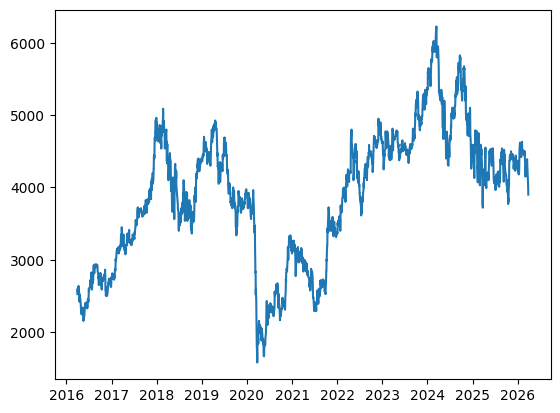

In [ ]:
plt.plot(df["Date"], df["Close"])

<Axes: xlabel='Close', ylabel='Count'>

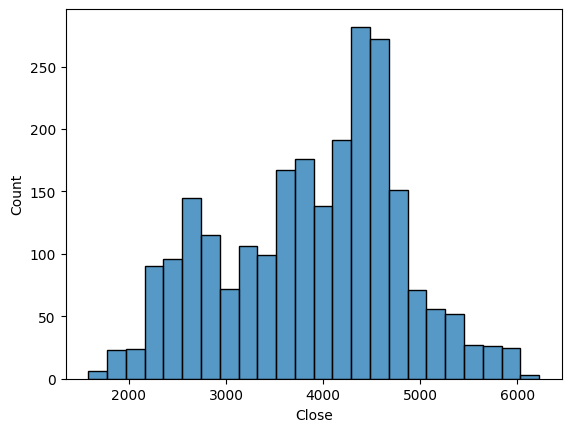

In [ ]:
sns.histplot(df["Close"])

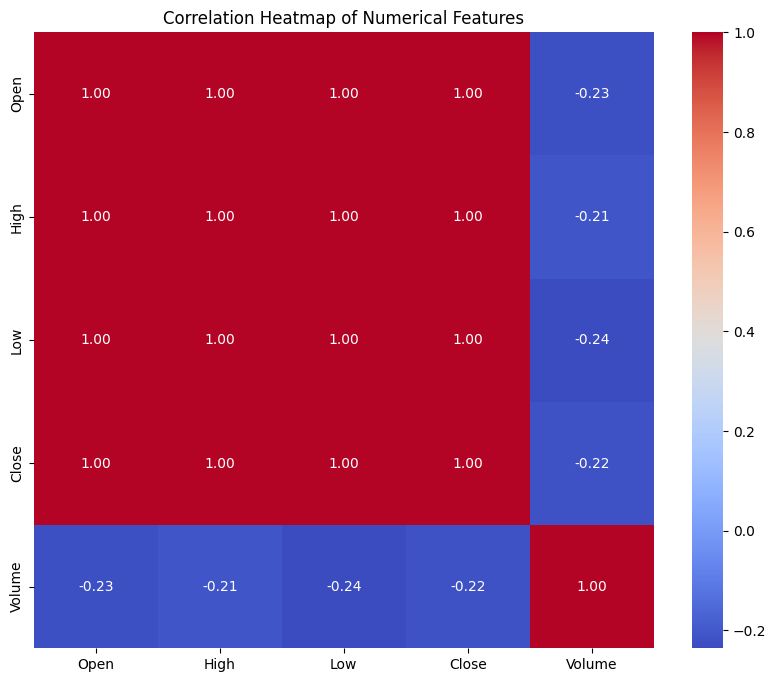

In [ ]:
numeric_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

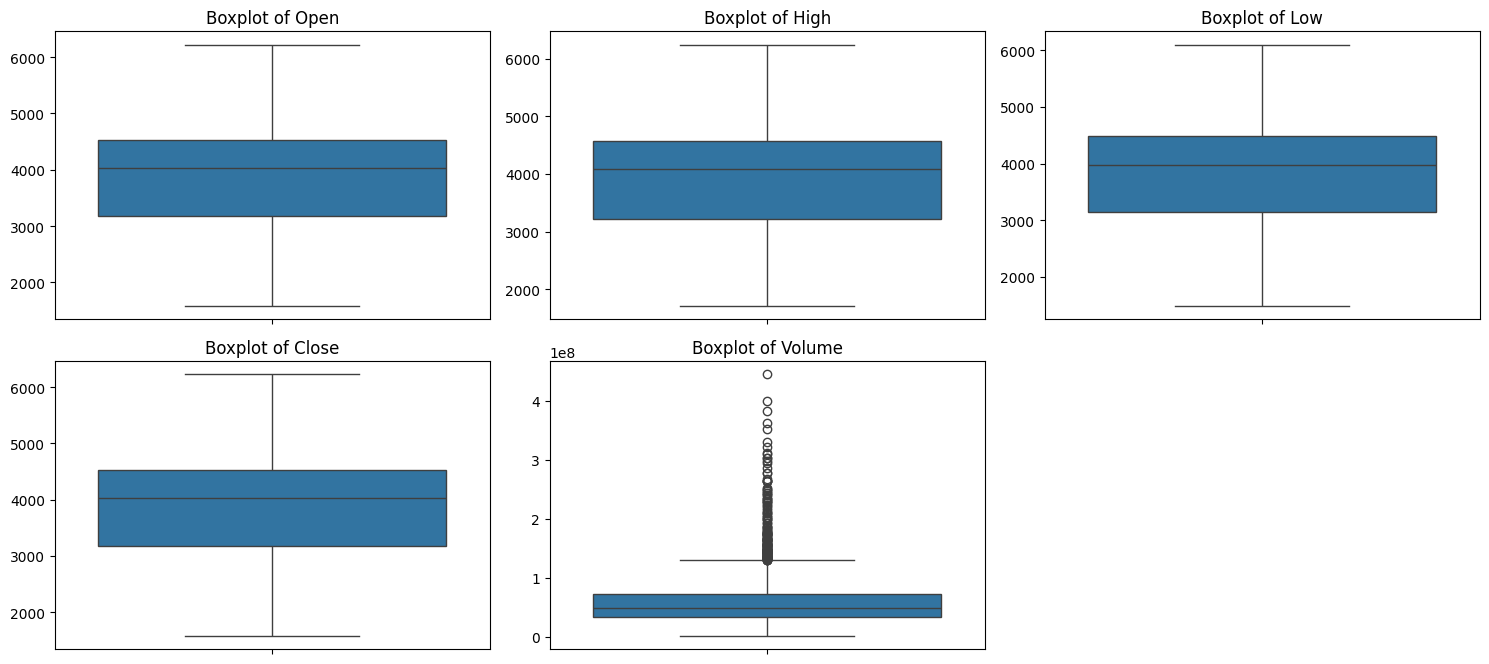

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed based on number of numerical columns
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

<Axes: >

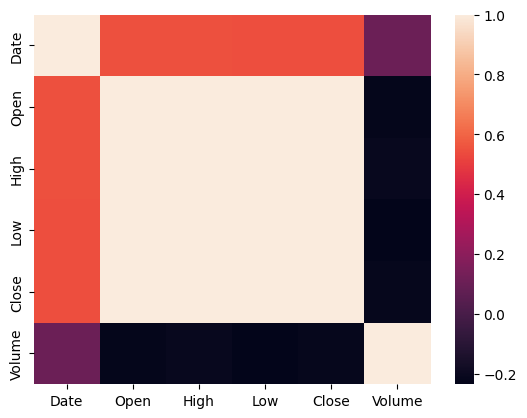

In [ ]:
sns.heatmap(df.corr())

STEP 5

In [ ]:
# Penambahan fitur

df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)
df['Lag_5'] = df['Close'].shift(5)
df['Return_1'] = df['Close'].pct_change(1)
df['Return_5'] = df['Close'].pct_change(5)
df['Volume_Change'] = df['Volume'].pct_change()
df['High_Low'] = df['High'] - df['Low']
df['Open_Close'] = df['Close'] - df['Open']

In [ ]:
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator, ROCIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

In [ ]:
# ===============================
# Trend Indicators
# ===============================

# Simple Moving Average (20 hari)
df["SMA20"] = SMAIndicator(
    close=df["Close"],
    window=20
).sma_indicator()

# ===============================
# Momentum Indicators
# ===============================

# Relative Strength Index
df["RSI"] = RSIIndicator(
    close=df["Close"],
    window=14
).rsi()

# ===============================
# MACD
# ===============================

macd = MACD(
    close=df["Close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_Signal"] = macd.macd_signal()
df["MACD_Diff"] = macd.macd_diff()

In [ ]:
print(df.head())

print("\nJumlah missing value:")
print(df.isnull().sum())

In [ ]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.shape)
print(df.head())

In [ ]:
technical_features = [
    "SMA20",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Diff"
]

print(df[technical_features].describe().T)

              count         mean         std          min          25%  \
SMA20        2380.0  3894.470588  901.488075  1852.500000  3213.281250   
RSI          2380.0    51.887675   11.812146    10.347920    43.837936   
MACD         2380.0     5.711988   84.849966  -499.542121   -35.189394   
MACD_Signal  2380.0     5.706536   79.819407  -430.696712   -33.162777   
MACD_Diff    2380.0     0.005452   25.754866  -121.493726   -14.654605   

                     50%          75%          max  
SMA20        4059.687500  4517.656250  5978.750000  
RSI            52.427110    60.064047    86.619674  
MACD           12.582142    62.364701   266.662939  
MACD_Signal    11.894708    59.643150   228.015188  
MACD_Diff      -0.032398    15.167583    81.277257  


STEP 6

In [ ]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
print(df.isnull().sum())

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
Lag_1            0
Lag_2            0
Lag_3            0
Lag_5            0
Return_1         0
Return_5         0
Volume_Change    0
High_Low         0
Open_Close       0
SMA20            0
RSI              0
MACD             0
MACD_Signal      0
MACD_Diff        0
dtype: int64


STEP 7

In [ ]:
df["Target"] = df["Close"].shift(-1)

In [ ]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

STEP 8

In [ ]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_5",
    "Return_1",
    "Return_5",
    "Volume_Change",
    "High_Low",
    "Open_Close",
    "SMA20",
    "MACD"
    "RSI"
]

MODEL BASELINE

In [ ]:
baseline_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

MODEL ENHANCED

In [ ]:
enhanced_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_5",
    "Return_1",
    "Return_5",
    "Volume_Change",
    "High_Low",
    "Open_Close",
    "SMA20",
    "RSI",
    "MACD"
]



```
# This is formatted as code
```

BOLINGER AND ROC

In [ ]:
enhanced_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_5",
    "Return_1",
    "Return_5",
    "Volume_Change",
    "High_Low",
    "Open_Close",
    "SMA20",
    "RSI",
    "MACD"
]

In [ ]:
X = df[enhanced_features]
y = df["Target"]

STEP 9

In [ ]:
X_baseline = df[baseline_features]
y = df["Target"]

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

baseline_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df), start=1):

    train = df.iloc[train_idx]
    test = df.iloc[test_idx]

    # Prediksi besok = harga hari ini
    y_true = test["Target"]
    y_pred = test["Close"]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    baseline_results.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [ ]:
baseline_results = pd.DataFrame(baseline_results)

baseline_results

,Fold,MAE,RMSE,R2
0,1,64.299242,86.385854,0.957489
1,2,54.027778,74.504889,0.987704
2,3,48.674242,67.036851,0.991588
3,4,55.909091,78.893668,0.969448
4,5,70.252525,97.349340,0.957474


In [ ]:
print("Baseline Performance")

print(f"Mean MAE  : {baseline_results['MAE'].mean():.4f}")
print(f"Std MAE   : {baseline_results['MAE'].std():.4f}")

print(f"Mean RMSE : {baseline_results['RMSE'].mean():.4f}")
print(f"Std RMSE  : {baseline_results['RMSE'].std():.4f}")

print(f"Mean R²   : {baseline_results['R2'].mean():.4f}")
print(f"Std R²    : {baseline_results['R2'].std():.4f}")

Baseline Performance
Mean MAE  : 58.6326
Std MAE   : 8.5867
Mean RMSE : 80.8341
Std RMSE  : 11.5949
Mean R²   : 0.9727
Std R²    : 0.0162


STEP 9A. Hyperparameter Tuning

Tujuan

Mencari kombinasi parameter Random Forest yang memberikan performa terbaik sebelum model digunakan untuk prediksi.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [ ]:
param_dist = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [
        None,
        5,
        10,
        20,
        30
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        "log2",
        None
    ],

    "bootstrap": [
        True,
        False
    ]
}

In [ ]:
X_baseline = df[baseline_features]
y = df["Target"]

In [ ]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search_baseline = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_dist,

    n_iter=30,

    scoring="neg_root_mean_squared_error",

    cv=tscv,

    random_state=42,

    n_jobs=-1,

    verbose=1

)

random_search_baseline.fit(
    X_baseline,
    y
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [ ]:
print("Best Parameters")
print(random_search_baseline.best_params_)

print()

print("Best RMSE")
print(-random_search_baseline.best_score_)

Best Parameters
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}

Best RMSE
153.7203259364992


In [ ]:
X_enhanced = df[enhanced_features]

In [ ]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search_enhanced = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_dist,

    n_iter=30,

    scoring="neg_root_mean_squared_error",

    cv=tscv,

    random_state=42,

    n_jobs=-1,

    verbose=1

)

random_search_enhanced.fit(
    X_enhanced,
    y
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [ ]:
print("Best Parameters")
print(random_search_enhanced.best_params_)

print()

print("Best RMSE")
print(-random_search_enhanced.best_score_)

Best Parameters
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}

Best RMSE
169.30984492393546


In [ ]:
best_params_baseline = random_search_baseline.best_params_

best_params_enhanced = random_search_enhanced.best_params_

STEP 10. Random Forest Baseline (OHLCV)

In [ ]:
X = df[baseline_features]
y = df["Target"]

In [ ]:
rf_baseline_results = []

feature_importance = []

prediction_results = []

In [ ]:
from sklearn.ensemble import RandomForestRegressor

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    rf = RandomForestRegressor(

        **best_params_baseline,

        random_state=42,

        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    rf_baseline_results.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    feature_importance.append(rf.feature_importances_)

    prediction_results.append(
        pd.DataFrame({
            "Date": df.iloc[test_idx]["Date"].values,
            "Actual": y_test.values,
            "Prediction": y_pred
        })
    )

In [ ]:
rf_baseline_results = pd.DataFrame(rf_baseline_results)

rf_baseline_results

,Fold,MAE,RMSE,R2
0,1,81.207473,105.102042,0.937072
1,2,87.817859,133.793724,0.960349
2,3,53.817624,72.843317,0.990068
3,4,203.702254,354.361135,0.383631
4,5,77.220763,102.501411,0.952853


In [ ]:
print("Random Forest Baseline")

print(f"Mean MAE  : {rf_baseline_results['MAE'].mean():.4f}")
print(f"Std MAE   : {rf_baseline_results['MAE'].std():.4f}")

print(f"Mean RMSE : {rf_baseline_results['RMSE'].mean():.4f}")
print(f"Std RMSE  : {rf_baseline_results['RMSE'].std():.4f}")

print(f"Mean R²   : {rf_baseline_results['R2'].mean():.4f}")
print(f"Std R²    : {rf_baseline_results['R2'].std():.4f}")

Random Forest Baseline
Mean MAE  : 100.7532
Std MAE   : 58.9589
Mean RMSE : 153.7203
Std RMSE  : 114.2169
Mean R²   : 0.8448
Std R²    : 0.2585


STEP 11. Random Forest Enhanced (OHLCV + Technical Indicators)

In [ ]:
X = df[enhanced_features]
y = df["Target"]

In [ ]:
rf_enhanced_results = []

feature_importance_enhanced = []

prediction_results_enhanced = []

In [ ]:
from sklearn.ensemble import RandomForestRegressor

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    rf = RandomForestRegressor(

        **best_params_enhanced,

        random_state=42,

        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    rf_enhanced_results.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


    feature_importance_enhanced.append(
        rf.feature_importances_
    )

    prediction_results_enhanced.append(
    pd.DataFrame({
        "Fold": fold,
        "Date": df.iloc[test_idx]["Date"].values,
        "Actual": y_test.values,
        "Prediction": y_pred
    })
  )

Fold 1: 2018-01-10 12:00:12 - 2019-09-02 12:00:12
Fold 2: 2019-09-03 12:00:12 - 2021-04-15 12:00:12
Fold 3: 2021-04-16 12:00:12 - 2022-11-24 12:00:12
Fold 4: 2022-11-25 12:00:12 - 2024-07-29 12:00:12
Fold 5: 2024-07-30 12:00:12 - 2026-03-26 12:00:12


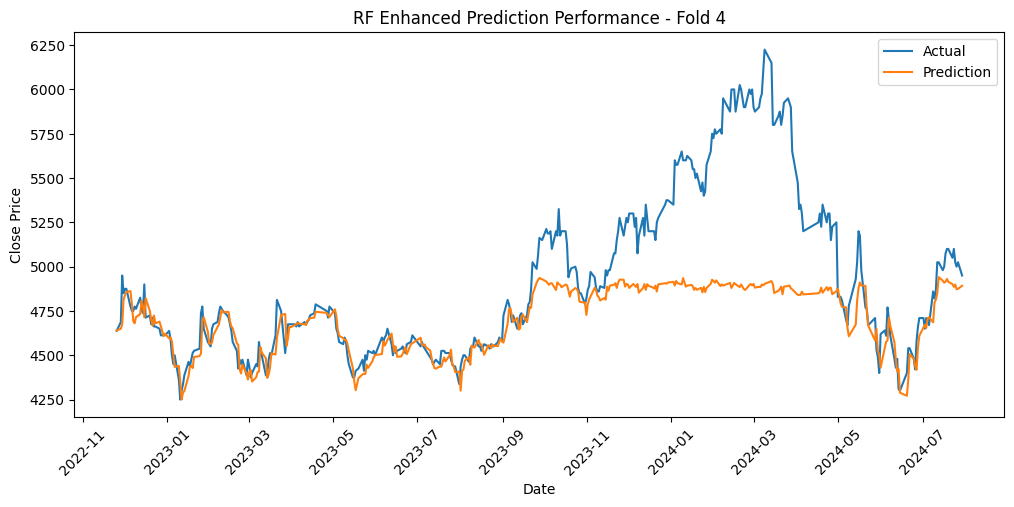

In [ ]:
prediction_results_enhanced_df = pd.concat(
    prediction_results_enhanced,
    ignore_index=True
)

for fold in range(1,6):
    temp = prediction_results_enhanced_df[
        prediction_results_enhanced_df["Fold"] == fold
    ]

    print(
        f"Fold {fold}:",
        temp["Date"].min(),
        "-",
        temp["Date"].max()
    )

fold4 = prediction_results_enhanced_df[
    prediction_results_enhanced_df["Fold"] == 4
]

plt.figure(figsize=(12,5))

plt.plot(
    fold4["Date"],
    fold4["Actual"],
    label="Actual"
)

plt.plot(
    fold4["Date"],
    fold4["Prediction"],
    label="Prediction"
)

plt.title("RF Enhanced Prediction Performance - Fold 4")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.show()



In [ ]:
fold4["Error"] = abs(
    fold4["Actual"] - fold4["Prediction"]
)

fold4.sort_values(
    "Error",
    ascending=False
).head(10)

/tmp/ipykernel_815/293939736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fold4["Error"] = abs(


,Fold,Date,Actual,Prediction,Error
1498,4,2024-03-08 12:00:12,6225.0,4902.538912,1322.461088
1499,4,2024-03-13 12:00:12,6150.0,4918.687895,1231.312105
1497,4,2024-03-07 12:00:12,6100.0,4894.188690,1205.811310
1484,4,2024-02-19 12:00:12,6025.0,4884.695883,1140.304117
1481,4,2024-02-13 12:00:12,6000.0,4879.794023,1120.205977
1491,4,2024-02-28 12:00:12,6000.0,4894.070933,1105.929067
1489,4,2024-02-26 12:00:12,6000.0,4896.355233,1103.644767
1485,4,2024-02-20 12:00:12,6000.0,4899.666022,1100.333978
1482,4,2024-02-15 12:00:12,6000.0,4907.965400,1092.034600
1496,4,2024-03-06 12:00:12,5975.0,4899.086706,1075.913294


In [ ]:
rf_enhanced_results = pd.DataFrame(rf_enhanced_results)

rf_enhanced_results

,Fold,MAE,RMSE,R2
0,1,113.436810,140.273875,0.887908
1,2,98.379469,149.628388,0.950408
2,3,54.741561,74.152041,0.989708
3,4,224.182542,380.905715,0.287831
4,5,76.042898,101.589205,0.953689


In [ ]:
print("Random Forest Enhanced")

print(f"Mean MAE  : {rf_enhanced_results['MAE'].mean():.4f}")
print(f"Std MAE   : {rf_enhanced_results['MAE'].std():.4f}")

print(f"Mean RMSE : {rf_enhanced_results['RMSE'].mean():.4f}")
print(f"Std RMSE  : {rf_enhanced_results['RMSE'].std():.4f}")

print(f"Mean R²   : {rf_enhanced_results['R2'].mean():.4f}")
print(f"Std R²    : {rf_enhanced_results['R2'].std():.4f}")

Random Forest Enhanced
Mean MAE  : 113.3567
Std MAE   : 65.8307
Mean RMSE : 169.3098
Std RMSE  : 122.1110
Mean R²   : 0.8139
Std R²    : 0.2964


STEP 12. Perbandingan Seluruh Model

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Naive Persistence",
        "RF Baseline",
        "RF Enhanced"
    ],

    "MAE":[
        baseline_results["MAE"].mean(),
        rf_baseline_results["MAE"].mean(),
        rf_enhanced_results["MAE"].mean()
    ],

    "RMSE":[
        baseline_results["RMSE"].mean(),
        rf_baseline_results["RMSE"].mean(),
        rf_enhanced_results["RMSE"].mean()
    ],

    "R2":[
        baseline_results["R2"].mean(),
        rf_baseline_results["R2"].mean(),
        rf_enhanced_results["R2"].mean()
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Naive Persistence,58.632576,80.834120,0.972741
1,RF Baseline,100.753195,153.720326,0.844795
2,RF Enhanced,113.356656,169.309845,0.813909


In [ ]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

print(best_model)

Model    Naive Persistence
MAE              58.632576
RMSE              80.83412
R2                0.972741
Name: 0, dtype: object


STEP 13. Visualisasi Perbandingan

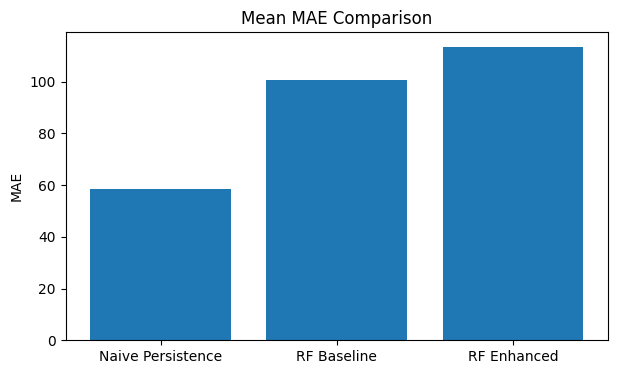

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.title("Mean MAE Comparison")
plt.ylabel("MAE")
plt.show()

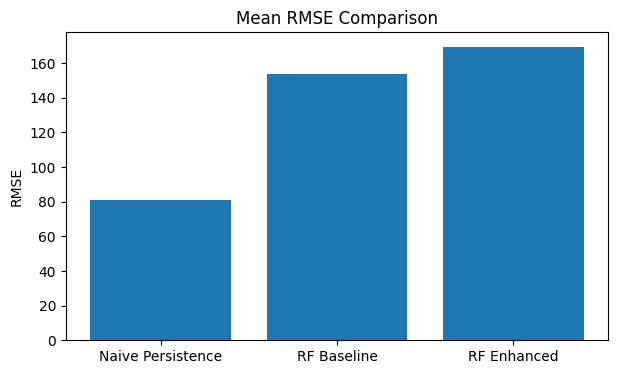

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("Mean RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

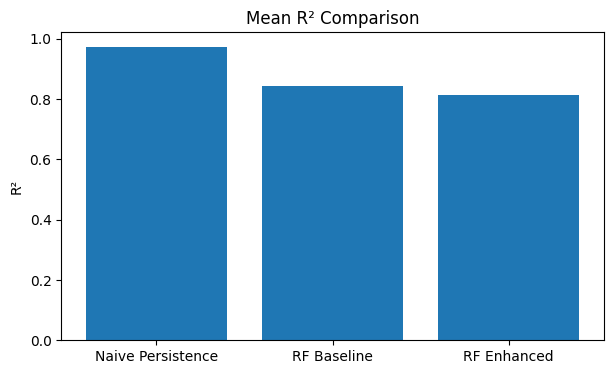

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.title("Mean R² Comparison")
plt.ylabel("R²")
plt.show()

STEP 14. Uji Statistik

Pengujian 1

Apakah RF Baseline lebih baik daripada Naive?

In [ ]:
wilcoxon(
    baseline_results["RMSE"],
    rf_baseline_results["RMSE"]
)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.0625))

Pengujian 2

Apakah RF Enhanced lebih baik daripada RF Baseline?

In [ ]:
wilcoxon(
    rf_baseline_results["RMSE"],
    rf_enhanced_results["RMSE"]
)

WilcoxonResult(statistic=np.float64(1.0), pvalue=np.float64(0.125))

In [ ]:
stat, p = wilcoxon(
    rf_baseline_results["RMSE"],
    rf_enhanced_results["RMSE"]
)

print(stat)
print(p)

1.0
0.125


PENGUJIAN 3

Apakah Random Forest + Technical Indicator lebih baik daripada Naive Persistence?

In [ ]:
stat, p = wilcoxon(
    baseline_results["RMSE"],
    rf_enhanced_results["RMSE"]
)

print(stat)
print(p)

0.0
0.0625


STEP 15. Feature Importance Analysis

In [ ]:
feature_importance_enhanced

[array([0.11273457, 0.20465992, 0.17035299, 0.16035961, 0.00048412,
        0.07714131, 0.05707268, 0.03940567, 0.03286712, 0.00039918,
        0.00067442, 0.00037638, 0.00094021, 0.00088982, 0.12082519,
        0.00357288, 0.01724395]),
 array([0.14978119, 0.20141227, 0.19790202, 0.18241136, 0.00062865,
        0.09034681, 0.05110598, 0.02919718, 0.03362185, 0.00112834,
        0.00102628, 0.00056092, 0.00231827, 0.00110766, 0.05356579,
        0.00122343, 0.00266198]),
 array([0.13620499, 0.21422811, 0.22840255, 0.16658463, 0.00368261,
        0.08100228, 0.06162038, 0.04999477, 0.02322558, 0.0012602 ,
        0.00096268, 0.00044222, 0.00042776, 0.00079083, 0.0261464 ,
        0.00184637, 0.00317766]),
 array([0.13963163, 0.23067943, 0.20969542, 0.16583442, 0.00182747,
        0.09661489, 0.05365928, 0.04751835, 0.02641641, 0.00100184,
        0.00091066, 0.00049358, 0.00042558, 0.00083277, 0.01958425,
        0.00183342, 0.00304059]),
 array([0.13052309, 0.19224693, 0.23434348, 0.20

In [ ]:
importance = np.mean(
    feature_importance_enhanced,
    axis=0
)

importance_df = pd.DataFrame({
    "Feature": enhanced_features,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
1,High,0.208645
2,Low,0.208139
3,Close,0.176024
0,Open,0.133775
5,Lag_1,0.085525
6,Lag_2,0.054400
14,SMA20,0.048447
7,Lag_3,0.043458
8,Lag_5,0.028404
16,MACD,0.005788


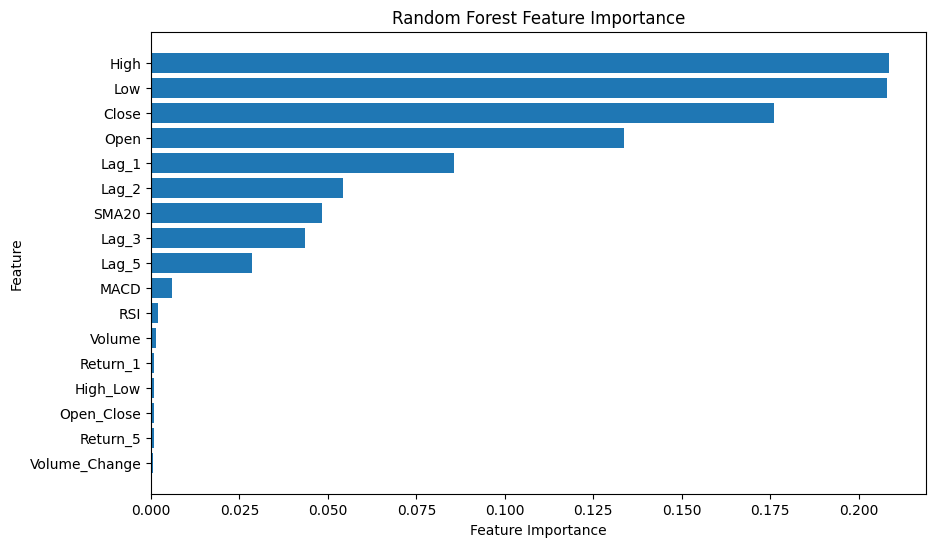

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

STEP 16. Actual vs Prediction

In [ ]:
prediction_df = pd.concat(
    prediction_results_enhanced,
    ignore_index=True
)

prediction_df.head()

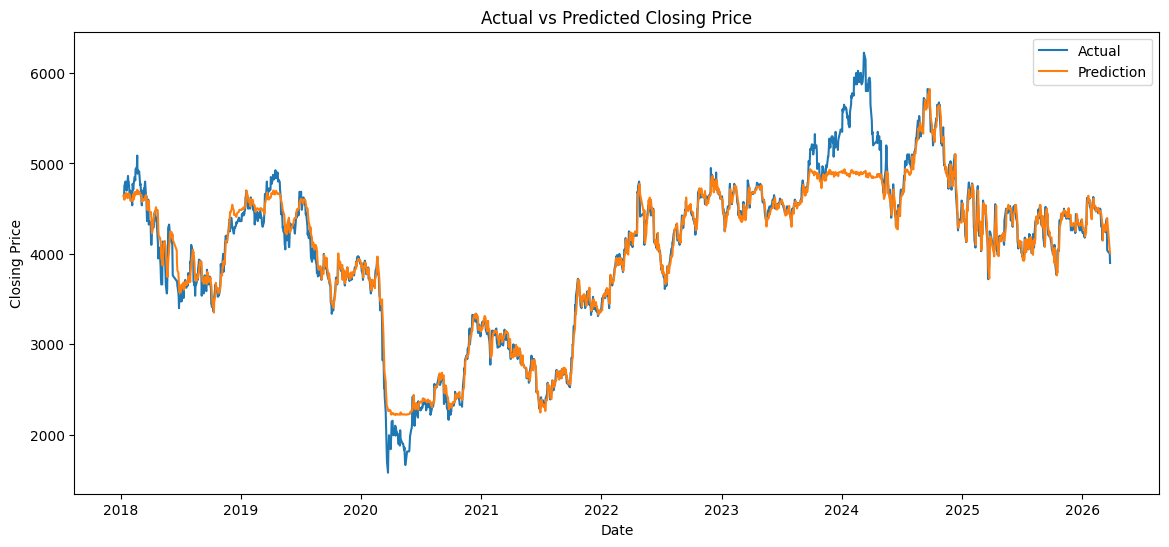

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    prediction_df["Date"],
    prediction_df["Actual"],
    label="Actual"
)

plt.plot(
    prediction_df["Date"],
    prediction_df["Prediction"],
    label="Prediction"
)

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.title("Actual vs Predicted Closing Price")

plt.legend()

plt.show()

STEP 17. Residual Analysis

*   List item
*   List item


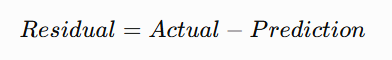

In [ ]:
prediction_df["Residual"] = (
    prediction_df["Actual"]
    -
    prediction_df["Prediction"]
)

In [ ]:
prediction_df["Residual"].describe()

,Residual
count,1980.000000
mean,21.270666
std,200.405930
min,-701.342494
25%,-61.731457
50%,-4.994658
75%,63.976178
max,1322.461088


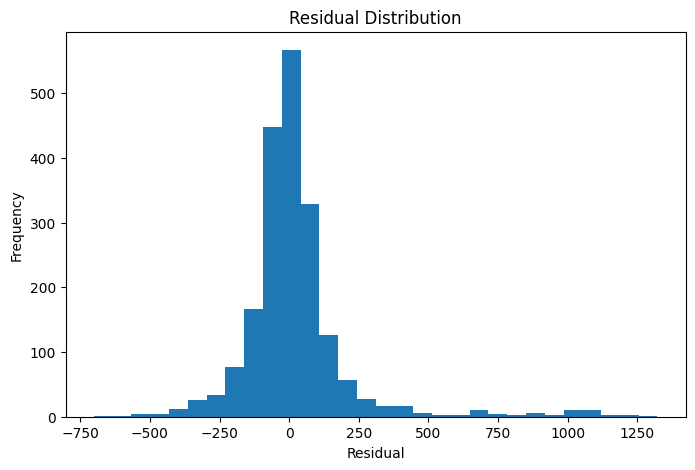

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    prediction_df["Residual"],
    bins=30
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

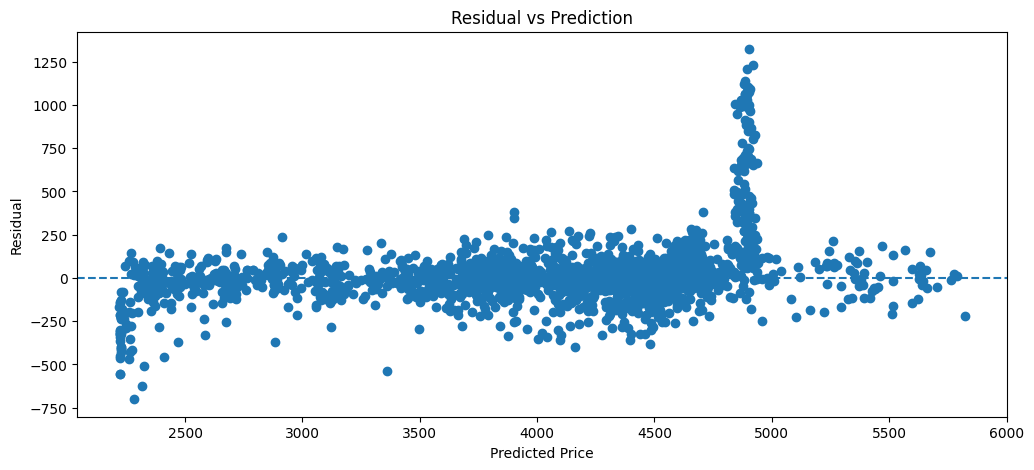

In [ ]:
plt.figure(figsize=(12,5))

plt.scatter(
    prediction_df["Prediction"],
    prediction_df["Residual"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual vs Prediction")

plt.show()

Idealnya residual menyebar acak. Kalau muncul pola misalnya Residual

 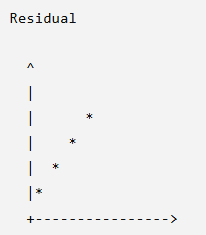

berarti model masih bias.

STEP 18. Ringkasan Seluruh Eksperimen

In [ ]:
summary = pd.DataFrame({

    "Model":[
        "Naive",
        "RF Baseline",
        "RF Enhanced"
    ],

    "Mean MAE":[
        baseline_results["MAE"].mean(),
        rf_baseline_results["MAE"].mean(),
        rf_enhanced_results["MAE"].mean()
    ],

    "Std MAE":[
        baseline_results["MAE"].std(),
        rf_baseline_results["MAE"].std(),
        rf_enhanced_results["MAE"].std()
    ],

    "Mean RMSE":[
        baseline_results["RMSE"].mean(),
        rf_baseline_results["RMSE"].mean(),
        rf_enhanced_results["RMSE"].mean()
    ],

    "Std RMSE":[
        baseline_results["RMSE"].std(),
        rf_baseline_results["RMSE"].std(),
        rf_enhanced_results["RMSE"].std()
    ],

    "Mean R2":[
        baseline_results["R2"].mean(),
        rf_baseline_results["R2"].mean(),
        rf_enhanced_results["R2"].mean()
    ],

    "Std R2":[
        baseline_results["R2"].std(),
        rf_baseline_results["R2"].std(),
        rf_enhanced_results["R2"].std()
    ]
})

summary

,Model,Mean MAE,Std MAE,Mean RMSE,Std RMSE,Mean R2,Std R2
0,Naive,58.632576,8.586680,80.834120,11.594863,0.972741,0.016246
1,RF Baseline,100.753195,58.958863,153.720326,114.216909,0.844795,0.258515
2,RF Enhanced,113.356656,65.830740,169.309845,122.110966,0.813909,0.296357


STEP 19. Analisis Tambahan

In [ ]:
# Statistik deskriptif (setelah hapus Volume=0)
desc = df[['Open', 'High', 'Low', 'Close', 'Volume']].describe()
print("Statistik Deskriptif :")
print(desc)

desc.to_excel('statistik_deskriptif_bbni.xlsx')



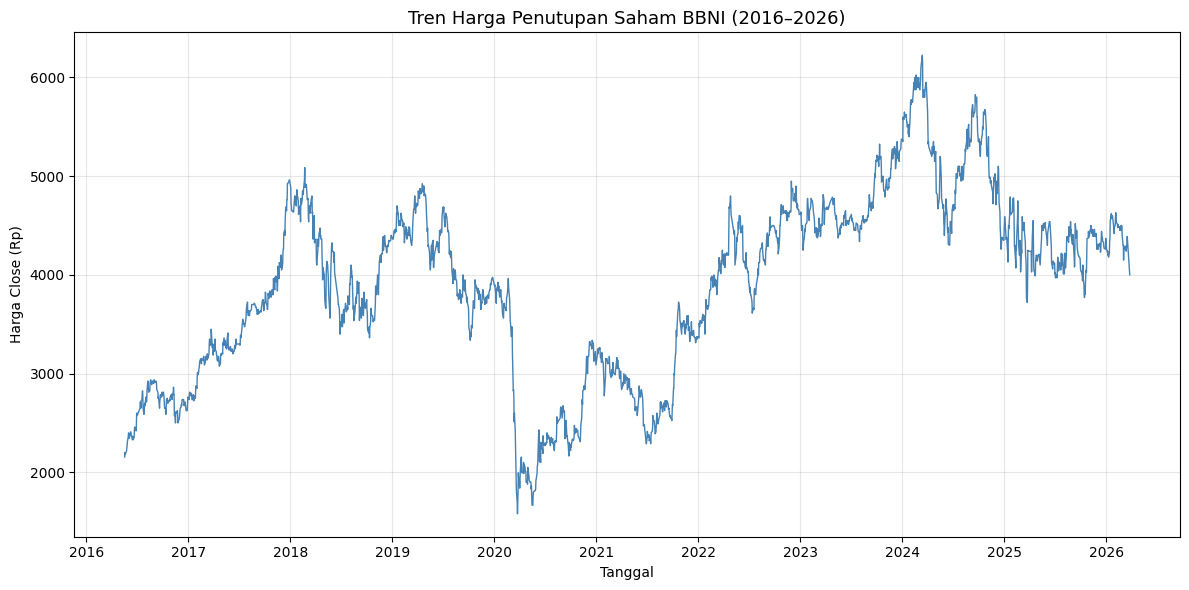

In [ ]:
# Plot tren harga Close
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], color='steelblue', linewidth=1)
plt.title('Tren Harga Penutupan Saham BBNI (2016–2026)', fontsize=13)
plt.xlabel('Tanggal')
plt.ylabel('Harga Close (Rp)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('trend_close_bbni_clean.png', dpi=300)
plt.show()

Fold 1: 2018-01-10 12:00:12 - 2019-09-02 12:00:12
Fold 2: 2019-09-03 12:00:12 - 2021-04-15 12:00:12
Fold 3: 2021-04-16 12:00:12 - 2022-11-24 12:00:12
Fold 4: 2022-11-25 12:00:12 - 2024-07-29 12:00:12
Fold 5: 2024-07-30 12:00:12 - 2026-03-26 12:00:12


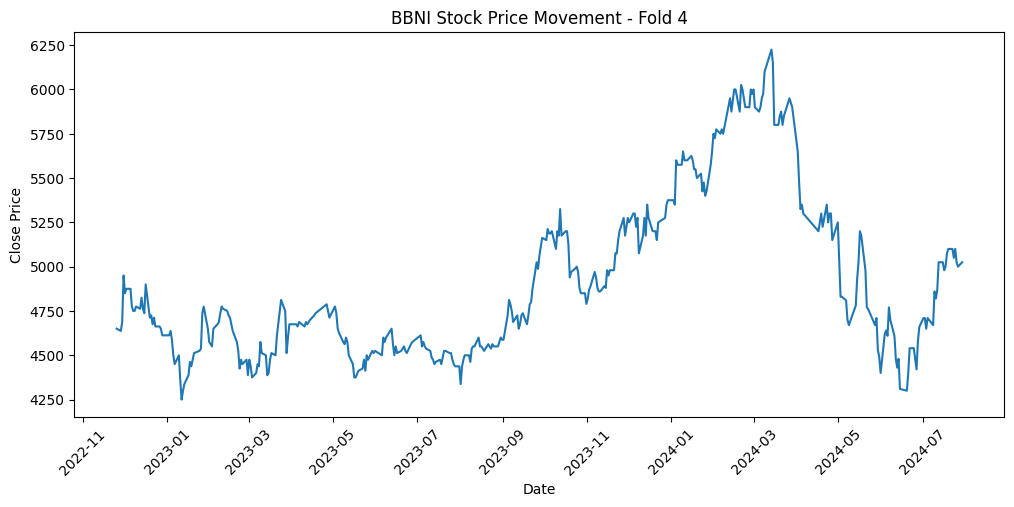

In [ ]:
for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    print(
        f"Fold {fold+1}:",
        df.iloc[test_idx]["Date"].min(),
        "-",
        df.iloc[test_idx]["Date"].max()
    )

fold = 4

train_idx, test_idx = list(tscv.split(df))[fold-1]

plt.figure(figsize=(12,5))

plt.plot(
    df.iloc[test_idx]["Date"],
    df.iloc[test_idx]["Close"]
)

plt.title("BBNI Stock Price Movement - Fold 4")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df["Return"] = df["Close"].pct_change()

for fold, (_, test_idx) in enumerate(tscv.split(df)):

    volatility = df.iloc[test_idx]["Return"].std()

    print(
        f"Fold {fold+1}: Volatility = {volatility}"
    )

Fold 1: Volatility = 0.021114930657312715
Fold 2: Volatility = 0.029273737747643108
Fold 3: Volatility = 0.018799494213441213
Fold 4: Volatility = 0.015813161793018303
Fold 5: Volatility = 0.022000366543345945
